# Lab 3: Predicting Stock Prices: Develop a time series prediction model to forecast stock prices.

In [3]:
import yfinance as yf
data = yf.download("AAPL", start="2018-01-01", end="2026-02-04")

[*********************100%***********************]  1 of 1 completed


In [5]:
print(data.tail(10))

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-21  247.418488  251.324836  244.950795  248.467509  54641700
2026-01-22  248.117844  250.765360  247.918018  248.967040  39708300
2026-01-23  247.808121  249.176850  244.451261  247.088808  41689000
2026-01-26  255.171234  256.320153  249.566478  251.244900  55969200
2026-01-27  258.028534  261.705117  257.968592  258.927717  49648300
2026-01-28  256.200287  258.618008  254.272083  257.409147  41288000
2026-01-29  258.038544  259.407258  254.172166  257.758807  67253000
2026-01-30  259.237427  261.655147  251.944233  254.931443  92443400
2026-02-02  269.757599  270.237131  258.967677  259.786917  73913400
2026-02-03  269.228088  271.625839  267.359811  268.948351  64394700


In [6]:
data.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
df = data.copy()
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600
2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400
2018-01-05,40.945263,41.031832,40.489016,40.580266,94640000
2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200
...,...,...,...,...,...
2026-01-28,256.200287,258.618008,254.272083,257.409147,41288000
2026-01-29,258.038544,259.407258,254.172166,257.758807,67253000


Lag1 → yesterday’s price

Lag2 → price two days ago

In [8]:
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

df.dropna(inplace=True)
df.head()


Price,Close,High,Low,Open,Volume,Lag1,Lag2,Lag3
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2018-01-05,40.945263,41.031832,40.489016,40.580266,94640000,40.484333,40.297157,40.304176
2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200,40.945263,40.484333,40.297157
2018-01-09,40.788506,40.959305,40.573251,40.839980,86336000,40.793175,40.945263,40.484333
2018-01-10,40.779137,40.781479,40.477313,40.514750,95839600,40.788506,40.793175,40.945263
2018-01-11,41.010765,41.059901,40.825928,40.849323,74670800,40.779137,40.788506,40.793175


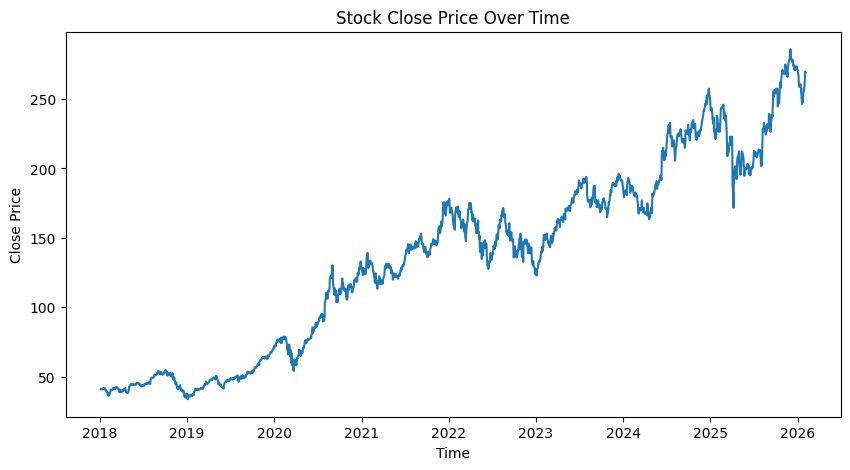

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Close Price Over Time")
plt.show()

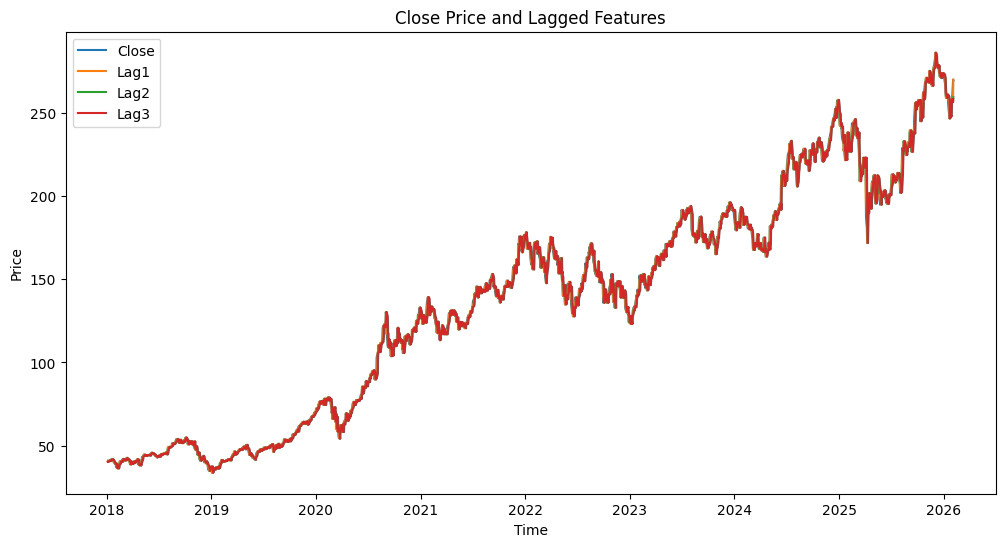

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['Lag1'], label='Lag1')
plt.plot(df['Lag2'], label='Lag2')
plt.plot(df['Lag3'], label='Lag3')

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Close Price and Lagged Features")
plt.legend()
plt.show()


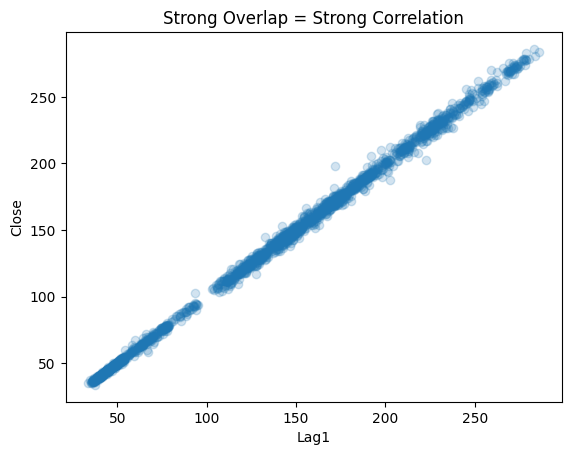

In [11]:
plt.scatter(df['Lag1'], df['Close'], alpha=0.2)

plt.xlabel("Lag1")
plt.ylabel("Close")
plt.title("Strong Overlap = Strong Correlation")
plt.show()


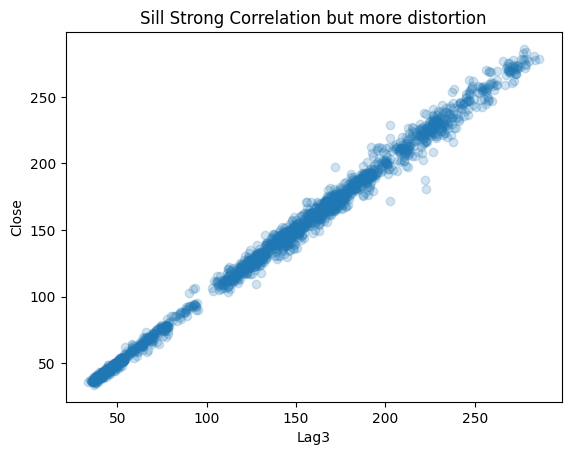

: 

In [ ]:
plt.scatter(df['Lag3'], df['Close'], alpha=0.2)

plt.xlabel("Lag3")
plt.ylabel("Close")
plt.title("Sill Strong Correlation but more distortion")
plt.show()

Define X and y

In [13]:
X = df[['Lag1', 'Lag2', 'Lag3']]
y = df['Close']

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = model.predict(X_test)

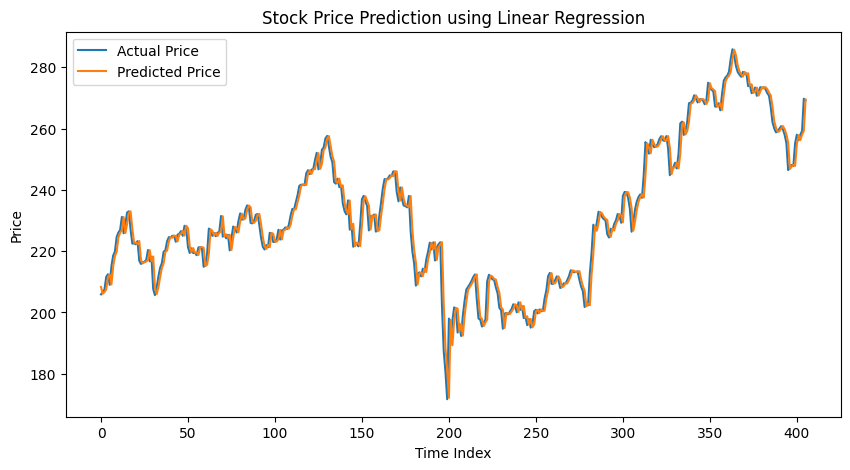

In [17]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.legend()
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time Index")
plt.ylabel("Price")

plt.show()
